In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.DataFrame({'Подразделение': ['Каменский СК', 'Осетровский СК','Каменский СК','Осетровский СК','Осетровский СК'],
                   'Падеж': [4, 5, 10, 12, 15]})
df.head()

,Подразделение,Падеж
0,Каменский СК,4
1,Осетровский СК,5
2,Каменский СК,10
3,Осетровский СК,12
4,Осетровский СК,15


In [36]:
df[df['Подразделение'] == 'Осетровский СК']

,Подразделение,Падеж
1,Осетровский СК,5
3,Осетровский СК,12
4,Осетровский СК,15


In [46]:
df.loc[df['Подразделение'] == 'Осетровский СК', 'Подразделение'] = 'Осетровский'

In [48]:
df

,Подразделение,Падеж
0,Каменский СК,4
1,Осетровский,5
2,Каменский СК,10
3,Осетровский,12
4,Осетровский,15


In [55]:
df = pd.DataFrame({'Подразделение': ['Каменский СК', 'Осетровский СК','Бутурлиновский СК','Буравлянский СК','Центральный СК', 'Бобровский СК', 'Таловский СК', 'Каменский СК', 'Осетровский СК','Бутурлиновский СК','Буравлянский СК','Центральный СК', 'Бобровский СК', 'Таловский СК'],
                   'Номенклатура': ['Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин'],
                   'Количество':[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   'Неделя': [1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2]}
                 )

In [68]:
nom_lst = ['Амоксициллин', 'N1', 'N2']

In [70]:
df_filter = df.query('Номенклатура in @nom_lst')

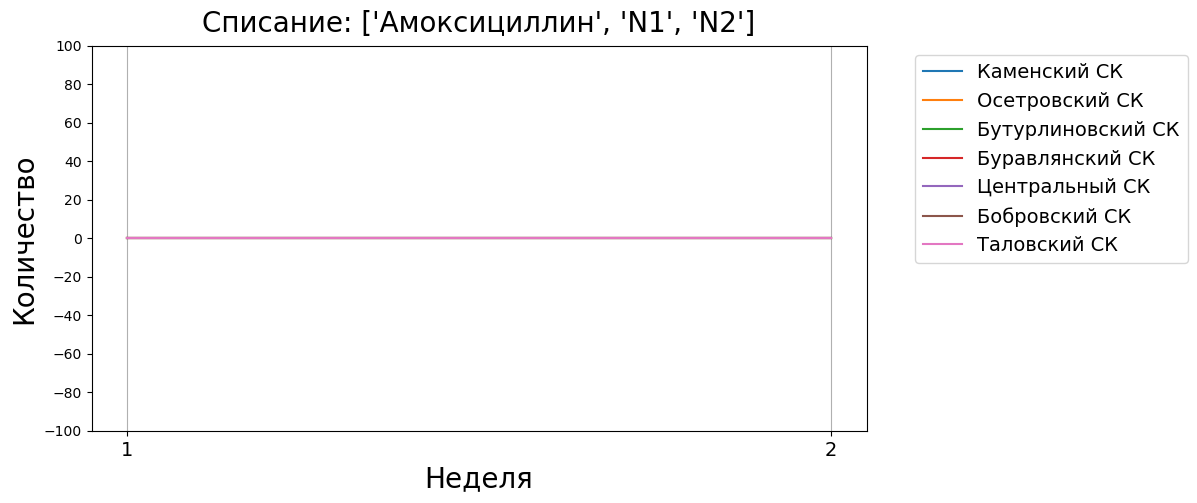

In [160]:
plt.figure(figsize=(10,5))

ax = sns.lineplot(data=df_filter, x='Неделя', y='Количество', hue = 'Подразделение')
ax.set_xlabel('Неделя', fontdict={'fontsize':20})
ax.set_ylabel('Количество', fontdict={'fontsize':20})

ax.set_title(f'Списание: {nom_lst}', fontdict={'fontsize':20, 'color':'black'}, pad=10)
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=14)
ax.grid(which='major', axis='x')

ax.set_xticks(ticks=[1, 2])
ax.tick_params(axis='x', labelsize = 14)
ax.set_yticks(ticks=np.linspace(-100, 100, 11));

In [63]:
pivot_df = df_filter.pivot(index='Подразделение', columns='Неделя', values='Количество')
pivot_df

Неделя,1,2
Подразделение,,
Бобровский СК,0,0
Буравлянский СК,0,0
Бутурлиновский СК,0,0
Каменский СК,0,0
Осетровский СК,0,0
Таловский СК,0,0
Центральный СК,0,0


(array([0.5, 1.5]), [Text(0.5, 0, '1'), Text(1.5, 0, '2')])

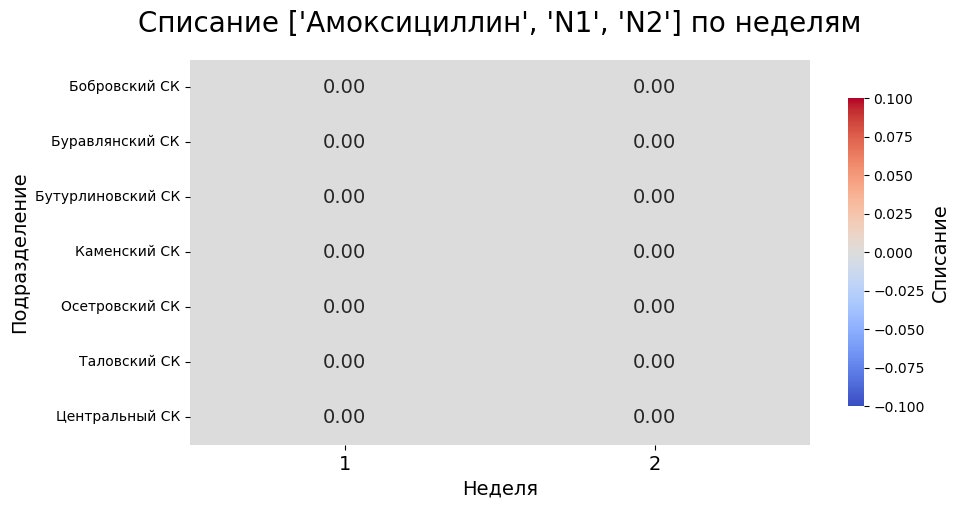

In [178]:
plt.figure(figsize=(10, 5))

ax = sns.heatmap(
        pivot_df, 
        annot=True,      # Пишем значения внутри ячеек
        cmap='coolwarm', # Цветовая гамма (синий-белый-красный)
        fmt=".2f",       # Формат чисел (2 знака после запятой)
        cbar_kws={'label': 'Списание', 'shrink': 0.8},
        annot_kws={'size': 14}  # размер текста в ячейках
    )

cbar = ax.collections[0].colorbar
cbar.set_label('Списание', size=14)  # размер label

plt.xlabel(xlabel='Неделя',fontdict={'fontsize':14})
plt.ylabel(ylabel='Подразделение',fontdict={'fontsize':14})
plt.title(f"Списание {nom_lst} по неделям", pad=20, fontdict={'fontsize':20})
plt.xticks(fontsize=14)